In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

In [2]:
# -- Data ----------------------------------------------------

CONTROL_POINTS = np.array([
    [0, 0, 1],   # P0
    [0, 4, 1],   # P1
    [4, 0, 1],   # P2
    [4, 4, 1],   # P3
    [5, 4, 1],   # P4
])

U_SNAPSHOTS    = [0.25, 0.50, 0.75]
SNAPSHOT_COLORS = ['#E91E63', '#FF6F00', '#6A1B9A']

In [3]:
# -- De Casteljau Computation --------------------------------

class DeCasteljauQuartic:
    """
    Quartic Bezier via De Casteljau algorithm.
    Computes all 4 reduction levels for visualization.

    Level 0 : P0..P4  (5 pts, control polygon)
    Level 1 : Q0..Q3  (4 pts)
    Level 2 : R0..R2  (3 pts)
    Level 3 : S0..S1  (2 pts)
    Level 4 : T0      (1 pt, curve point)
    """

    def __init__(self, points: np.ndarray):
        self.points = points

    def _lerp(
        self,
        a: np.ndarray,
        b: np.ndarray,
        u: float
    ) -> np.ndarray:
        """Linear interpolation between a and b at u."""
        return (1 - u) * a + u * b

    def _reduce(
        self, pts: np.ndarray, u: float
    ) -> np.ndarray:
        """One reduction step: n points -> n-1 points."""
        return np.array([
            self._lerp(pts[i], pts[i + 1], u)
            for i in range(len(pts) - 1)
        ])

    def steps(self, u: float) -> dict:
        """Return all level point arrays at parameter u."""
        l0 = self.points
        l1 = self._reduce(l0, u)
        l2 = self._reduce(l1, u)
        l3 = self._reduce(l2, u)
        l4 = self._reduce(l3, u)
        return {
            'level0': l0,
            'level1': l1,
            'level2': l2,
            'level3': l3,
            'level4': l4,
        }

    def point(self, u: float) -> np.ndarray:
        """Return final curve point at u."""
        return self.steps(u)['level4'][0]

    def curve(self, n: int = 300) -> np.ndarray:
        """Return smooth curve array."""
        u_vals = np.linspace(0, 1, n)
        return np.array([self.point(u) for u in u_vals])

In [4]:
# -- Plot ----------------------------------------------------

class DeCasteljauPlot3D:
    """
    Single 3D figure showing De Casteljau quartic.
    All u-snapshots overlaid on one chart.
    """

    COLOR_CURVE   = '#1565C0'
    COLOR_POLYGON = '#424242'

    # Line styles per level (excluding level 0)
    LEVEL_STYLE = {
        'level1': dict(linewidth=1.4, linestyle='-'),
        'level2': dict(linewidth=1.2, linestyle='--'),
        'level3': dict(linewidth=1.0, linestyle=':'),
    }

    # Marker sizes per level
    LEVEL_MSIZE = {
        'level1': 20,
        'level2': 20,
        'level3': 20,
        'level4': 60,
    }

    CTRL_NAMES = [
        'P0(0,0,1)', 'P1(0,4,1)',
        'P2(4,0,1)', 'P3(4,4,1)', 'P4(5,4,1)'
    ]
    CTRL_OFFSET = [
        (-0.5, -0.4,  0.06),
        (-0.5,  0.3,  0.06),
        ( 0.2, -0.4,  0.06),
        ( 0.2,  0.3,  0.06),
        ( 0.2,  0.15, 0.06),
    ]

    def __init__(
        self,
        bezier: DeCasteljauQuartic,
        u_snapshots: list,
        colors: list
    ):
        self.bezier      = bezier
        self.u_snapshots = u_snapshots
        self.colors      = colors
        self.fig, self.ax = self._init_figure()

    def _init_figure(self):
        """Initialize 3D figure with seaborn palette."""
        sns.set_theme(style='whitegrid')
        fig = plt.figure(figsize=(10, 7))
        ax  = fig.add_subplot(111, projection='3d')
        return fig, ax

    # -- Static elements -------------------------------------

    def _draw_curve(self):
        """Draw the full smooth Bezier curve."""
        pts = self.bezier.curve()
        self.ax.plot(
            pts[:, 0], pts[:, 1], pts[:, 2],
            color=self.COLOR_CURVE,
            linewidth=2.5,
            label='Bezier Curve',
            zorder=2
        )

    def _draw_control_polygon(self):
        """Draw dashed control polygon P0..P4."""
        pts = self.bezier.points
        self.ax.plot(
            pts[:, 0], pts[:, 1], pts[:, 2],
            color=self.COLOR_POLYGON,
            linestyle='--',
            linewidth=1.4,
            marker='o',
            markersize=6,
            label='Control Polygon',
            zorder=3
        )

    def _label_control_points(self):
        """Label P0..P4 beside each control point."""
        for pt, name, (dx, dy, dz) in zip(
            self.bezier.points,
            self.CTRL_NAMES,
            self.CTRL_OFFSET
        ):
            self.ax.text(
                pt[0] + dx,
                pt[1] + dy,
                pt[2] + dz,
                name,
                fontsize=7.5,
                color=self.COLOR_POLYGON,
                fontweight='bold'
            )

    # -- Per-snapshot elements -------------------------------

    def _draw_level(
        self,
        pts: np.ndarray,
        color: str,
        style: dict,
        msize: int
    ):
        """Draw one reduction level: line + dots."""
        self.ax.plot(
            pts[:, 0], pts[:, 1], pts[:, 2],
            color=color,
            alpha=0.75,
            zorder=4,
            **style
        )
        self.ax.scatter(
            pts[:, 0], pts[:, 1], pts[:, 2],
            color=color,
            s=msize,
            alpha=0.85,
            zorder=5
        )

    def _draw_final_point(
        self, pt: np.ndarray, color: str
    ):
        """Draw T0 — the final curve point."""
        self.ax.scatter(
            pt[0], pt[1], pt[2],
            color=color,
            s=80,
            marker='D',
            zorder=6
        )

    def _label_final_point(
        self, pt: np.ndarray, u: float, color: str
    ):
        """Label T0 with u and coordinates."""
        self.ax.text(
            pt[0] + 0.15,
            pt[1] + 0.15,
            pt[2] + 0.05,
            f'T0(u={u:.2f})\n'
            f'({pt[0]:.2f},{pt[1]:.2f},{pt[2]:.2f})',
            fontsize=6.5,
            color=color,
            fontweight='bold'
        )

    def _draw_snapshot(self, u: float, color: str):
        """Draw all reduction levels for one u value."""
        data = self.bezier.steps(u)

        for key in ['level1', 'level2', 'level3']:
            self._draw_level(
                data[key], color,
                self.LEVEL_STYLE[key],
                self.LEVEL_MSIZE[key]
            )

        t0 = data['level4'][0]
        self._draw_final_point(t0, color)
        self._label_final_point(t0, u, color)

    # -- Legend ----------------------------------------------

    def _make_legend(self):
        """Build and attach the figure legend."""
        handles = [
            mlines.Line2D(
                [], [],
                color=self.COLOR_CURVE,
                linewidth=2.5,
                label='Bezier Curve'
            ),
            mlines.Line2D(
                [], [],
                color=self.COLOR_POLYGON,
                linestyle='--',
                marker='o',
                markersize=5,
                label='Control Polygon (L0)'
            ),
        ]
        styles = [
            ('L1: solid',   '-',  5),
            ('L2: dashed',  '--', 5),
            ('L3: dotted',  ':',  5),
        ]
        for label, ls, ms in styles:
            handles.append(mlines.Line2D(
                [], [],
                color='#888888',
                linestyle=ls,
                marker='o',
                markersize=ms,
                label=label
            ))
        for u, color in zip(
            self.u_snapshots, self.colors
        ):
            handles.append(mlines.Line2D(
                [], [],
                color=color,
                linewidth=1.5,
                marker='D',
                markersize=5,
                label=f'u={u:.2f}'
            ))
        self.ax.legend(
            handles=handles,
            fontsize=8,
            loc='upper left'
        )

    # -- Decoration ------------------------------------------

    def _set_decorations(self):
        """Set title, axis labels, limits and view."""
        self.ax.set_title(
            'De Casteljau Algorithm — Quartic Bezier',
            fontsize=13,
            fontweight='bold',
            pad=16
        )
        self.ax.set_xlabel('x', fontsize=9, labelpad=8)
        self.ax.set_ylabel('y', fontsize=9, labelpad=8)
        self.ax.set_zlabel('z', fontsize=9, labelpad=8)
        self.ax.set_xlim(-0.5, 6)
        self.ax.set_ylim(-0.5, 5)
        self.ax.set_zlim(0,    2)
        self.ax.view_init(elev=25, azim=-55)

    # -- Main ------------------------------------------------

    def draw(self):
        """Compose all elements onto the single chart."""
        self._draw_curve()
        self._draw_control_polygon()
        self._label_control_points()

        for u, color in zip(
            self.u_snapshots, self.colors
        ):
            self._draw_snapshot(u, color)

        self._make_legend()
        self._set_decorations()

    def save(self, filename: str):
        """Save figure to file (relative path)."""
        self.fig.tight_layout()
        self.fig.savefig(filename, dpi=150)
        print(f'Saved: {filename}')

    def show(self):
        """Display the figure."""
        self.fig.tight_layout()
        plt.show()

In [5]:
# -- Entry Point ---------------------------------------------

def main() -> int:
    bezier = DeCasteljauQuartic(CONTROL_POINTS)
    plot   = DeCasteljauPlot3D(
        bezier, U_SNAPSHOTS, SNAPSHOT_COLORS
    )
    plot.draw()
    plot.save('22-bezier_decasteljau_quartic.png')
    plot.show()
    return 0

Saved: 22-bezier_decasteljau_quartic.png


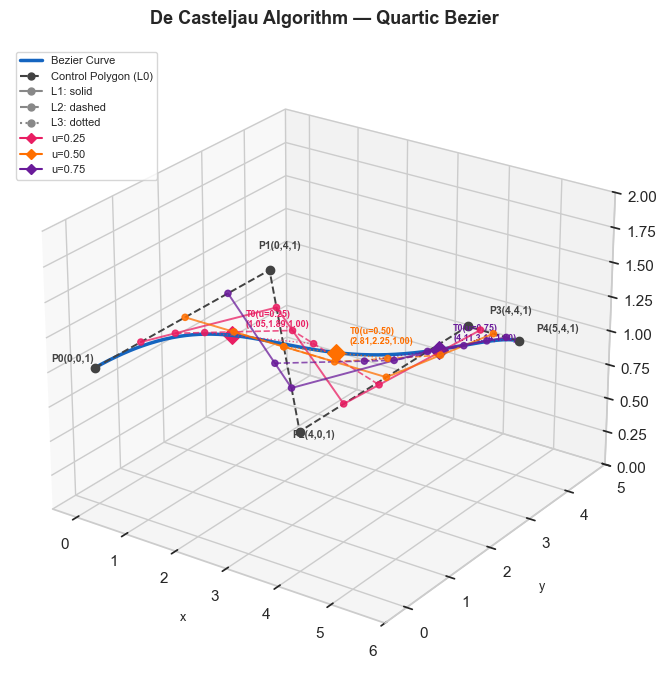

0

In [6]:
main()